In [41]:
import sys
from pathlib import Path
sys.path[:0] = [str(Path.cwd().parent)]

from concurrent.futures import ThreadPoolExecutor
import os

import numpy as np
import scipy.linalg as la
import matplotlib.pyplot as plt

from scripts.constants import PI, s2  # type: ignore
from scripts.utils import is_hermitian

from scripts.Hamiltonian import Hamiltonian
from scripts.Lattice import Lattice
from scripts.self_consistency import bdg_sc

In [82]:
X, Y = 25, 100
lattice = Lattice(X, Y, pbc_x=False)

t = 1
mu = 1.8 * t * np.ones(lattice.X)
T = 0.01

V0 = 1.5 * t
V = V0 * np.ones(lattice.X)

init_seed = np.linspace(0.01, 0.6, 5)
print(init_seed)
plot_arr = []

for seed in init_seed:
    F_arr = []
    F_arr.append(seed)
    H = Hamiltonian(t, mu, lattice, 
                    U=None, V_prime=None, V=V,
                    F_init=[seed, -seed, 1j*seed , -1j*seed])
    for i in range(40):
        F_swave, F_dwave, F_px, F_py = bdg_sc(H, rtol=0.01, maxiter=1, temperature=T)
        F_arr.append(np.real(F_px[X//2]))
    plot_arr.append(F_arr)

[0.01   0.1575 0.305  0.4525 0.6   ]


In [83]:
for i in range(len(init_seed)):
    print(plot_arr[i])

[np.float64(0.01), np.float64(0.015828249476628184), np.float64(0.02464400013397973), np.float64(0.03711545572280728), np.float64(0.05268828396484229), np.float64(0.06976213697083095), np.float64(0.08651446280791905), np.float64(0.10167326427239422), np.float64(0.1147303540183909), np.float64(0.1257124672820938), np.float64(0.1348842273926379), np.float64(0.14255920669194888), np.float64(0.14901851866546503), np.float64(0.15448984645889086), np.float64(0.15915111961395845), np.float64(0.16314083592969614), np.float64(0.16656804952064408), np.float64(0.16952013604024363), np.float64(0.17206834217881956), np.float64(0.17427163659023973), np.float64(0.17617938759384388), np.float64(0.17783326705313846), np.float64(0.17926865041385814), np.float64(0.18051568481934316), np.float64(0.181600131649589), np.float64(0.18254404889199827), np.float64(0.1833663542291144), np.float64(0.18408329537039578), np.float64(0.1847088457900615), np.float64(0.18525503908084096), np.float64(0.1857322520798281)

(array([-0.1,  0. ,  0.1,  0.2,  0.3,  0.4,  0.5,  0.6,  0.7]),
 [Text(0, -0.1, '−0.1'),
  Text(0, 0.0, '0.0'),
  Text(0, 0.1, '0.1'),
  Text(0, 0.20000000000000004, '0.2'),
  Text(0, 0.30000000000000004, '0.3'),
  Text(0, 0.4, '0.4'),
  Text(0, 0.5000000000000001, '0.5'),
  Text(0, 0.6000000000000001, '0.6'),
  Text(0, 0.7000000000000001, '0.7')])

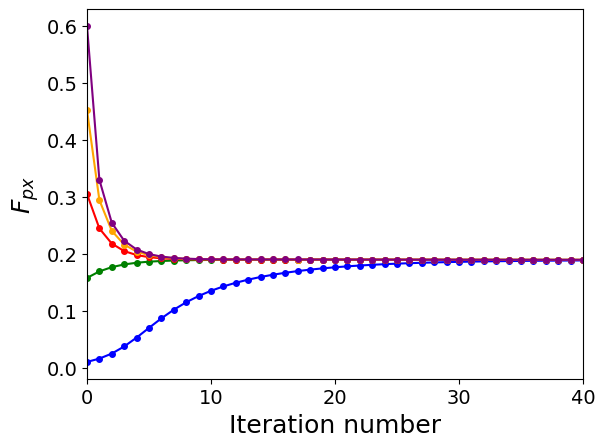

In [148]:
plt.plot(plot_arr[0], '-o', markersize=4, label=f'seed={init_seed[0]:.2f}', color='blue')
plt.plot(plot_arr[1], '-o', markersize=4, label=f'seed={init_seed[1]:.2f}', color='green')
plt.plot(plot_arr[2], '-o', markersize=4, label=f'seed={init_seed[2]:.2f}', color='red')
plt.plot(plot_arr[3], '-o', markersize=4, label=f'seed={init_seed[3]:.2f}', color='orange')
plt.plot(plot_arr[4], '-o', markersize=4, label=f'seed={init_seed[4]:.2f}', color='purple')
# plt.yscale('log')
plt.xlabel('Iteration number', fontsize=18)
plt.ylabel(r'$F_{px}$', fontsize=18)
plt.xlim(0, 40)
plt.xticks([0,10,20,30,40], fontsize=14)
plt.yticks(fontsize=14)

In [97]:
X, Y = 25, 100
lattice = Lattice(X, Y, pbc_x=False)

t = 1
mu = 1.8 * t * np.ones(lattice.X)
T = 0.01

V0_arr = [0.5 * t, 0.75 * t, 1.25 * t, 1.5 * t, 1.75 * t]
plot_arr2 = []

for V0 in V0_arr:
    V = V0 * np.ones(lattice.X)
    F_arr = [0.5]
    H = Hamiltonian(t, mu, lattice, 
                    U=None, V_prime=None, V=V,
                    F_init=[0.5, -0.5, 0.5j , -0.5j])
    for i in range(40):
        F_swave, F_dwave, F_px, F_py = bdg_sc(H, rtol=0.01, maxiter=1, temperature=T)
        F_arr.append(np.real(F_px[X//2]))
    plot_arr2.append(F_arr)

(array([0. , 0.1, 0.2, 0.3, 0.4, 0.5]),
 [Text(0, 0.0, '0.0'),
  Text(0, 0.1, '0.1'),
  Text(0, 0.2, '0.2'),
  Text(0, 0.30000000000000004, '0.3'),
  Text(0, 0.4, '0.4'),
  Text(0, 0.5, '0.5')])

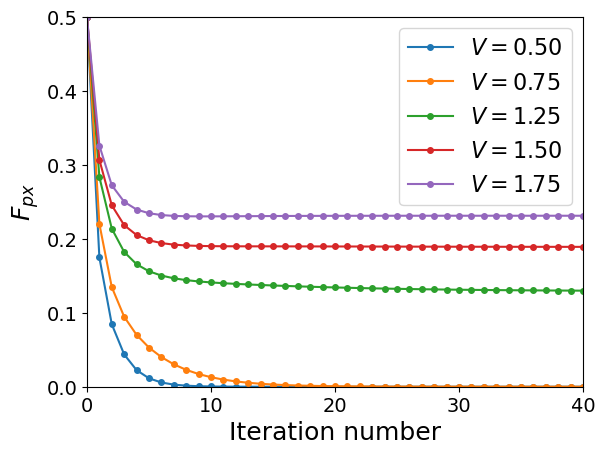

In [106]:
plt.plot(plot_arr2[0], '-o', markersize=4, label=rf'$V={V0_arr[0]:.2f}$')
plt.plot(plot_arr2[1], '-o', markersize=4, label=rf'$V={V0_arr[1]:.2f}$')
plt.plot(plot_arr2[2], '-o', markersize=4, label=rf'$V={V0_arr[2]:.2f}$')
plt.plot(plot_arr2[3], '-o', markersize=4, label=rf'$V={V0_arr[3]:.2f}$')
plt.plot(plot_arr2[4], '-o', markersize=4, label=rf'$V={V0_arr[4]:.2f}$')
plt.legend(fontsize=16)
plt.xlabel('Iteration number', fontsize=18)
plt.ylabel(r'$F_{px}$', fontsize=18)
plt.xlim(0, 40)
plt.ylim(0, 0.5)
plt.xticks([0,10,20,30,40], fontsize=14)
plt.yticks(fontsize=14)

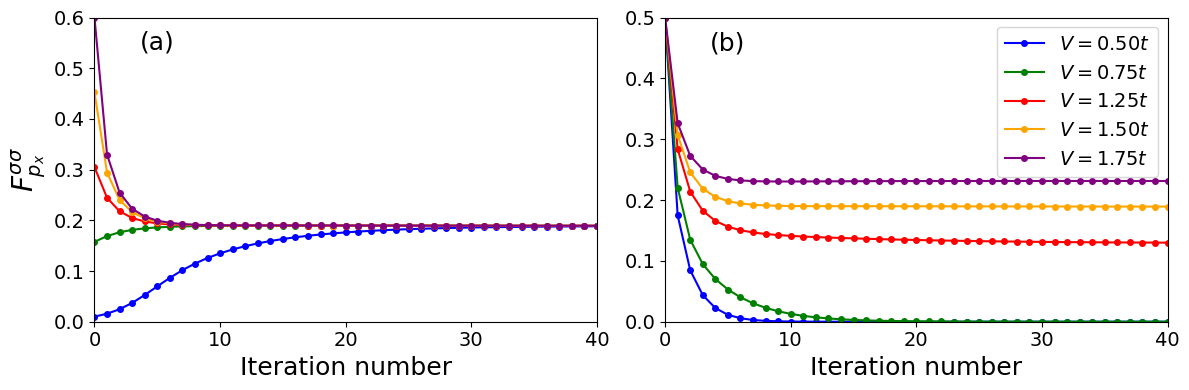

In [184]:
from turtle import color


fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(plot_arr[0], '-o', markersize=4, label=f'seed={init_seed[0]:.2f}', color='blue')
ax[0].plot(plot_arr[1], '-o', markersize=4, label=f'seed={init_seed[1]:.2f}', color='green')
ax[0].plot(plot_arr[2], '-o', markersize=4, label=f'seed={init_seed[2]:.2f}', color='red')
ax[0].plot(plot_arr[3], '-o', markersize=4, label=f'seed={init_seed[3]:.2f}', color='orange')
ax[0].plot(plot_arr[4], '-o', markersize=4, label=f'seed={init_seed[4]:.2f}', color='purple')
ax[0].set_xlabel('Iteration number', fontsize=18)
ax[0].set_ylabel(r'$F^{\sigma\sigma}_{p_x}$', fontsize=20)
ax[0].set_xlim(0, 40)
ax[0].set_ylim(0, 0.6)
ax[0].text(5, 0.55, '(a)', fontsize=18, horizontalalignment='center', verticalalignment='center')
ax[0].set_xticks([0, 10, 20, 30, 40])
ax[0].tick_params(axis='x', labelsize=14)
ax[0].tick_params(axis='y', labelsize=14)

ax[1].plot(plot_arr2[0], '-o', markersize=4, label=rf'$V={V0_arr[0]:.2f}t$', color='blue')
ax[1].plot(plot_arr2[1], '-o', markersize=4, label=rf'$V={V0_arr[1]:.2f}t$', color='green')
ax[1].plot(plot_arr2[2], '-o', markersize=4, label=rf'$V={V0_arr[2]:.2f}t$', color='red')
ax[1].plot(plot_arr2[3], '-o', markersize=4, label=rf'$V={V0_arr[3]:.2f}t$', color='orange')
ax[1].plot(plot_arr2[4], '-o', markersize=4, label=rf'$V={V0_arr[4]:.2f}t$', color='purple')
ax[1].set_xlabel('Iteration number', fontsize=18)
ax[1].set_xlim(0, 40)
ax[1].set_ylim(0, 0.5)
ax[1].legend(fontsize=14)
ax[1].text(5, 0.458, '(b)', fontsize=18, horizontalalignment='center', verticalalignment='center')
ax[1].set_xticks([0, 10, 20, 30, 40])
ax[1].tick_params(axis='x', labelsize=14)
ax[1].tick_params(axis='y', labelsize=14)

plt.tight_layout()
plt.savefig('../figures/convergence_plots.pdf', bbox_inches='tight')

In [153]:
X, Y = 25, 100
lattice = Lattice(X, Y, pbc_x=False)

t = 1
mu = 1.8 * t * np.ones(lattice.X)
T = 0.01

V0 = 1.5 * t
V_prime = V0 * np.ones(lattice.X)

init_seed = np.linspace(0.01, 0.6, 5)
print(init_seed)
plot_arr_uu = []
plot_arr_dd = []

for seed in init_seed:
    Fuu_arr = []
    Fdd_arr = []
    Fuu_arr.append(seed)
    Fdd_arr.append(seed)
    
    H = Hamiltonian(t, mu, lattice, 
                    U=None, V_prime=V_prime, V=None,
                    Fuu_init=[seed, -seed, 1j*seed , -1j*seed],
                    Fdd_init=[seed, -seed, 1j*seed , -1j*seed])
    for i in range(40):
        F_swave, F_dwave, F_px, F_py = bdg_sc(H, rtol=0.01, maxiter=1, temperature=T)
        F, Fuu, Fdd = H.get_correlations()
        Fuu_arr.append(np.real(Fuu.px[X//2]))
        Fdd_arr.append(np.real(Fdd.px[X//2]))

    plot_arr_uu.append(Fuu_arr)
    plot_arr_dd.append(Fdd_arr)

[0.01   0.1575 0.305  0.4525 0.6   ]


In [179]:
X, Y = 25, 100
lattice = Lattice(X, Y, pbc_x=False)

t = 1
mu = 1.8 * t * np.ones(lattice.X)
T = 0.01

V0_arr = [0.5 * t, 0.75 * t, 1.25 * t, 1.5 * t, 1.75 * t]
plot_arr_uu2 = []
plot_arr_dd2 = []

for V0 in V0_arr:
    V_prime = V0 * np.ones(lattice.X)
    Fuu_arr = [0.5]
    Fdd_arr = [0.5]
    
    H = Hamiltonian(t, mu, lattice, 
                    U=None, V_prime=V_prime, V=None,
                    Fuu_init=[0.5, -0.5, 0.5j , -0.5j],
                    Fdd_init=[0.5, -0.5, 0.5j , -0.5j])
    for i in range(40):
        F_swave, F_dwave, F_px, F_py = bdg_sc(H, rtol=0.01, maxiter=1, temperature=T)
        F, Fuu, Fdd = H.get_correlations()
        Fuu_arr.append(np.real(Fuu.px[X//2]))
        Fdd_arr.append(np.real(Fdd.px[X//2]))

    plot_arr_uu2.append(Fuu_arr)
    plot_arr_dd2.append(Fdd_arr)

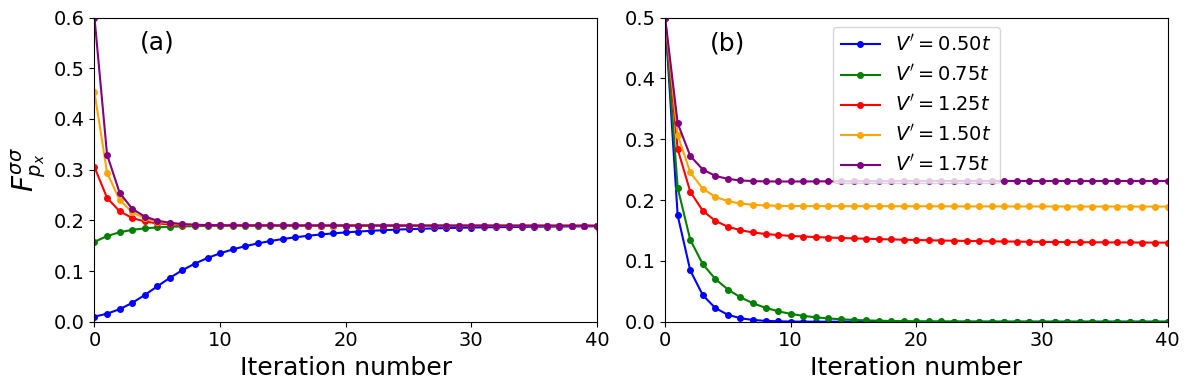

In [183]:
from turtle import color


fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(plot_arr_uu[0], '-o', markersize=4, label=f'seed={init_seed[0]:.2f}', color='blue')
ax[0].plot(plot_arr_uu[1], '-o', markersize=4, label=f'seed={init_seed[1]:.2f}', color='green')
ax[0].plot(plot_arr_uu[2], '-o', markersize=4, label=f'seed={init_seed[2]:.2f}', color='red')
ax[0].plot(plot_arr_uu[3], '-o', markersize=4, label=f'seed={init_seed[3]:.2f}', color='orange')
ax[0].plot(plot_arr_uu[4], '-o', markersize=4, label=f'seed={init_seed[4]:.2f}', color='purple')
ax[0].set_xlabel('Iteration number', fontsize=18)
ax[0].set_ylabel(r'$F^{\sigma\sigma}_{p_x}$', fontsize=20)
ax[0].set_xlim(0, 40)
ax[0].set_ylim(0, 0.6)
ax[0].text(5, 0.55, '(a)', fontsize=18, horizontalalignment='center', verticalalignment='center')
ax[0].set_xticks([0, 10, 20, 30, 40])
ax[0].tick_params(axis='x', labelsize=14)
ax[0].tick_params(axis='y', labelsize=14)

ax[1].plot(plot_arr_dd2[0], '-o', markersize=4, label=rf"$V'={V0_arr[0]:.2f}t$", color='blue')
ax[1].plot(plot_arr_dd2[1], '-o', markersize=4, label=rf"$V'={V0_arr[1]:.2f}t$", color='green')
ax[1].plot(plot_arr_dd2[2], '-o', markersize=4, label=rf"$V'={V0_arr[2]:.2f}t$", color='red')
ax[1].plot(plot_arr_dd2[3], '-o', markersize=4, label=rf"$V'={V0_arr[3]:.2f}t$", color='orange')
ax[1].plot(plot_arr_dd2[4], '-o', markersize=4, label=rf"$V'={V0_arr[4]:.2f}t$", color='purple')
ax[1].set_xlabel('Iteration number', fontsize=18)
ax[1].set_xlim(0, 40)
ax[1].set_ylim(0, 0.5)
ax[1].legend(fontsize=14)
ax[1].text(5, 0.458, '(b)', fontsize=18, horizontalalignment='center', verticalalignment='center')
ax[1].set_xticks([0, 10, 20, 30, 40])
ax[1].tick_params(axis='x', labelsize=14)
ax[1].tick_params(axis='y', labelsize=14)

plt.tight_layout()
plt.savefig('../figures/convergence_plots_prime.pdf', bbox_inches='tight')